## Setup
### Imports

In [ ]:
import os
import re

import polars as pl
from scipy import stats

from lipidimea._lipidlib.parser import parse_lipid_name

from lipi.refpath.manager import RefPathManager
from lipi.translation.yaml import ingest_yaml_pathway
from lipi.network import load_pathway
from lipi.visualization import plot_pathway_layout, plot_pathway_stats
from lipi.stats import load_stats_from_csv
from lipi.mapping import map_omics_data_to_pathway

### Constants

In [ ]:
# assumes jupyter notebook server is running at the base of the repo
BASE_DIR = os.path.join(os.getcwd(), "demos", "cptac_3_gbm")

FIGURES_DIR = os.path.join(BASE_DIR, "_figures")
OMICS_DATA_DIR = os.path.join(BASE_DIR, "_omics_data")
OMICS_SAMPLE_LABELS = os.path.join(OMICS_DATA_DIR, "labels.csv")
RAW_OMICS_DATA = {
    "lipidomics_pos": os.path.join(OMICS_DATA_DIR, "lipidomics_pos.csv"),
    "lipidomics_neg": os.path.join(OMICS_DATA_DIR, "lipidomics_neg.csv"),
    "metabolomics": os.path.join(OMICS_DATA_DIR, "metabolomics_pos.csv"),
    "transcriptomics": os.path.join(OMICS_DATA_DIR, "transcriptomics.csv"),
    "proteomics": os.path.join(OMICS_DATA_DIR, "proteomics.csv"),
}
PROCESSED_OMICS_DATA = {
    "metabolomics": os.path.join(OMICS_DATA_DIR, "metabolomics_deltaz.csv"),
    "lipidomics": os.path.join(OMICS_DATA_DIR, "lipidomics_deltaz.csv"),
    "transcriptomics": os.path.join(OMICS_DATA_DIR, "transcriptomics_deltaz.csv"),
    "proteomics": os.path.join(OMICS_DATA_DIR, "proteomics_deltaz.csv")
}

REFPATH_FILE = os.path.join(BASE_DIR, "refpath.db")
YAML_FILE = os.path.join(BASE_DIR, "pathway.yaml")

### Load and pre-process omics data

#### Select samples for comparison (nmf2 vs. nmf1/3)

In [36]:
sample_labels = (
    pl.read_csv(OMICS_SAMPLE_LABELS)
)
sample_labels

case,nmf_consensus
str,str
"""C3L-00104""","""nmf1"""
"""C3L-00365""","""nmf3"""
"""C3L-00674""","""nmf1"""
"""C3L-00677""","""nmf1"""
"""C3L-01040""","""nmf1"""
…,…
"""PT-RN5K""","""GTEXnormal"""
"""PT-RU72""","""GTEXnormal"""
"""PT-UTHO""","""GTEXnormal"""


In [37]:
nmf2_samples = (
    sample_labels
    .filter(
        pl.col("nmf_consensus") == "nmf2"
    )
    ["case"]
    .to_list()
)
len(nmf2_samples)

38

In [38]:
nmf13_samples = (
    sample_labels
    .filter(
        pl.col("nmf_consensus").is_in(["nmf1"])
    )
    ["case"]
    .to_list()
)
len(nmf13_samples)

33

In [39]:
gtex_samples = (
    sample_labels
    .filter(
        pl.col("nmf_consensus") == "GTEXnormal"
    )
    ["case"]
    .to_list()
)
len(gtex_samples)

10

#### Metabolomics

In [40]:
metabolomics = (
    pl.read_csv(
        RAW_OMICS_DATA["metabolomics"],
        null_values="NA"
    )
    .rename({"Metabolite": "feature"})
    # select the samples for the target comparison: nmf2 vs. nmf1
    # group raw values into a list
    .select(
        "feature",
        pl.selectors.by_name(nmf2_samples + nmf13_samples, require_all=False)
    )
)

# figure out which of the samples were actually present in the dataset
metabolomics_samples_nmf2 = list(set(metabolomics.columns) & set(nmf2_samples))
metabolomics_samples_nmf13 = list(set(metabolomics.columns) & set(nmf13_samples))

# write ∆z data for nmf2 vs. nmf1/2 comparison to CSV
(
    metabolomics
    .select(
        "feature",
        (
            # pack the raw values into a list column
            pl.concat_list(
                metabolomics_samples_nmf2 + metabolomics_samples_nmf13
            )
            # compute row-wise z-scores
            .map_elements(
                lambda x: stats.zscore(x, nan_policy="omit"), 
                return_dtype=pl.List(pl.Float64)
            )
            # convert list to struct 
            .list.to_struct(
                fields=metabolomics_samples_nmf2 + metabolomics_samples_nmf13
            )
            .alias("packed")
        )
    )
    # unpack struct with z-scores back to sample columns
    .unnest("packed")
    # z-score makes NaNs out of null values, change them back
    .fill_nan(None)
    # group the samples into lists, drop null values
    .select(
        "feature",
        (
            pl.concat_list(metabolomics_samples_nmf2)
            .list.drop_nulls()
            .alias("nmf2")
        ),
        (
            pl.concat_list(metabolomics_samples_nmf13)
            .list.drop_nulls()
            .alias("nmf13")
        ),
    )
    # ensure there are sufficient values in each group to support comparison
    .filter(
        (pl.col("nmf2").list.len() >= 5)
        & (pl.col("nmf13").list.len() >= 5)
    )
    # compute ∆z
    .with_columns(
        (
            pl.col("nmf2").list.mean() - pl.col("nmf13").list.mean()
        )
        .alias("delta_z")
    )
    .drop(
        "nmf2",
        "nmf13"
    )
    .write_csv(PROCESSED_OMICS_DATA["metabolomics"])
)

#### Lipidomics

In [41]:
def fix_lipid_names(name):
    # add L prefix to lysophospholipids
    if re.match(r'P.+ ((.+\/0:0)|(0:0\/))', name):
        name = "L" + name
    l = parse_lipid_name(name)
    if hasattr(l, "sn_pos_is_known"):
        # treat chain-resolved species as though their chain
        # positions are unknown
        l.sn_pos_is_known = False  # type: ignore
    return str(l)

In [42]:
lipidomics = (
    pl.concat(
        [
            pl.read_csv(
                RAW_OMICS_DATA["lipidomics_pos"],
                null_values="NA"
            ),
            pl.read_csv(
                RAW_OMICS_DATA["lipidomics_neg"],
                null_values="NA"
            )
        ],
        how="diagonal"
    )
    .rename({"Lipid": "feature"})
    # select the samples for the target comparison: nmf2 vs. nmf1/3
    # group raw values into a list
    .select(
        "feature",
        pl.selectors.by_name(nmf2_samples + nmf13_samples, require_all=False)
    )
)

# figure out which of the samples were actually present in the dataset
lipidomics_samples_nmf2 = list(set(lipidomics.columns) & set(nmf2_samples))
lipidomics_samples_nmf13 = list(set(lipidomics.columns) & set(nmf13_samples))

(
    lipidomics
    .with_columns(
        pl.col("feature")
        # make some formatting changes to lipid names so they can be parsed
        .str.replace_many({
            "(": " ",
            ")": "",
            "carnitine": "CAR",
        })
    )
    # split out multiple lipid annotations separated by ; into separate rows
    .with_columns(
        pl.col("feature")
        .str.split(";")
    )
    .explode("feature")
    # remove suffices _A, _B, ... from lipid IDs
    .with_columns(
        pl.col("feature")
        .str.replace("_[A-Z]$", "")
        .str.replace_many({
            "SM d": "SM ",
            "Cer d": "Cer "
        })
    )
    .with_columns(
        pl.col("feature")
        .map_elements(fix_lipid_names, return_dtype=pl.String)
    )
    .select(
        "feature",
        (
            # pack the raw values into a list column
            pl.concat_list(
                lipidomics_samples_nmf2 + lipidomics_samples_nmf13
            )
            # compute row-wise z-scores
            .map_elements(
                lambda x: stats.zscore(x, nan_policy="omit"), 
                return_dtype=pl.List(pl.Float64)
            )
            # convert list to struct 
            .list.to_struct(
                fields=lipidomics_samples_nmf2 + lipidomics_samples_nmf13
            )
            .alias("packed")
        )
    )
    # unpack struct with z-scores back to sample columns
    .unnest("packed")
    # z-score makes NaNs out of null values, change them back
    .fill_nan(None)
    # group the samples into lists, drop null values
    .select(
        "feature",
        (
            pl.concat_list(lipidomics_samples_nmf2)
            .list.drop_nulls()
            .alias("nmf2")
        ),
        (
            pl.concat_list(lipidomics_samples_nmf13)
            .list.drop_nulls()
            .alias("nmf13")
        ),
    )
    # ensure there are sufficient values in each group to support comparison
    .filter(
        (pl.col("nmf2").list.len() >= 5)
        & (pl.col("nmf13").list.len() >= 5)
    )
    # compute ∆z
    .with_columns(
        (
            pl.col("nmf2").list.mean() - pl.col("nmf13").list.mean()
        )
        .alias("delta_z")
    )
    .drop(
        "nmf2",
        "nmf13"
    )
    .write_csv(PROCESSED_OMICS_DATA["lipidomics"])
)

#### Proteomics

In [43]:
proteomics = (
    pl.read_csv(
        RAW_OMICS_DATA["proteomics"],
        null_values="NA"
    )
    .rename({"symbol": "feature"})
    # select the samples for the target comparison: nmf2 vs. nmf1/3
    # group raw values into a list
    .select(
        "feature",
        pl.selectors.by_name(nmf2_samples + nmf13_samples, require_all=False)
    )
)

# figure out which of the samples were actually present in the dataset
proteomics_samples_nmf2 = list(set(proteomics.columns) & set(nmf2_samples))
proteomics_samples_nmf13 = list(set(proteomics.columns) & set(nmf13_samples))

# write ∆z data for nmf2 vs. nmf1/2 comparison to CSV
(
    proteomics
    .select(
        "feature",
        (
            # pack the raw values into a list column
            pl.concat_list(
                proteomics_samples_nmf2 + proteomics_samples_nmf13
            )
            # compute row-wise z-scores
            .map_elements(
                lambda x: stats.zscore(x, nan_policy="omit"), 
                return_dtype=pl.List(pl.Float64)
            )
            # convert list to struct 
            .list.to_struct(
                fields=proteomics_samples_nmf2 + proteomics_samples_nmf13
            )
            .alias("packed")
        )
    )
    # unpack struct with z-scores back to sample columns
    .unnest("packed")
    # z-score makes NaNs out of null values, change them back
    .fill_nan(None)
    # group the samples into lists, drop null values
    .select(
        "feature",
        (
            pl.concat_list(proteomics_samples_nmf2)
            .list.drop_nulls()
            .alias("nmf2")
        ),
        (
            pl.concat_list(proteomics_samples_nmf13)
            .list.drop_nulls()
            .alias("nmf13")
        ),
    )
    # ensure there are sufficient values in each group to support comparison
    .filter(
        (pl.col("nmf2").list.len() >= 5)
        & (pl.col("nmf13").list.len() >= 5)
    )
    # compute ∆z
    .with_columns(
        (
            pl.col("nmf2").list.mean() - pl.col("nmf13").list.mean()
        )
        .alias("delta_z")
    )
    .drop(
        "nmf2",
        "nmf13"
    )
    .write_csv(PROCESSED_OMICS_DATA["proteomics"])
)

#### Transcriptopmics

In [44]:
transcriptomics = (
    pl.read_csv(
        RAW_OMICS_DATA["transcriptomics"],
        null_values="NA"
    )
    .rename({"gene_name": "feature"})
    # select the samples for the target comparison: nmf2 vs. nmf1/3
    # group raw values into a list
    .select(
        "feature",
        pl.selectors.by_name(nmf2_samples + nmf13_samples, require_all=False)
    )
)

# figure out which of the samples were actually present in the dataset
transcriptomics_samples_nmf2 = list(set(transcriptomics.columns) & set(nmf2_samples))
transcriptomics_samples_nmf13 = list(set(transcriptomics.columns) & set(nmf13_samples))

# write ∆z data for nmf2 vs. nmf1/2 comparison to CSV
(
    transcriptomics
    # apply log2 normalization to all values
    .with_columns(
        pl.selectors.numeric()
        .log(2.)
    )
    .select(
        "feature",
        (
            # pack the raw values into a list column
            pl.concat_list(
                transcriptomics_samples_nmf2 + transcriptomics_samples_nmf13
            )
            # compute row-wise z-scores
            .map_elements(
                lambda x: stats.zscore(x, nan_policy="omit"), 
                return_dtype=pl.List(pl.Float64)
            )
            # convert list to struct 
            .list.to_struct(
                fields=transcriptomics_samples_nmf2 + transcriptomics_samples_nmf13
            )
            .alias("packed")
        )
    )
    # unpack struct with z-scores back to sample columns
    .unnest("packed")
    # z-score makes NaNs out of null values, change them back
    .fill_nan(None)
    # group the samples into lists, drop null values
    .select(
        "feature",
        (
            pl.concat_list(transcriptomics_samples_nmf2)
            .list.drop_nulls()
            .alias("nmf2")
        ),
        (
            pl.concat_list(transcriptomics_samples_nmf13)
            .list.drop_nulls()
            .alias("nmf13")
        ),
    )
    # ensure there are sufficient values in each group to support comparison
    .filter(
        (pl.col("nmf2").list.len() >= 5)
        & (pl.col("nmf13").list.len() >= 5)
    )
    # compute ∆z
    .with_columns(
        (
            pl.col("nmf2").list.mean() - pl.col("nmf13").list.mean()
        )
        .alias("delta_z")
    )
    .drop(
        "nmf2",
        "nmf13"
    )
    .write_csv(PROCESSED_OMICS_DATA["transcriptomics"])
)

## Pathway analysis
### Ingest from YAML

In [45]:
# create the reference pathway database
RefPathManager.create(REFPATH_FILE, overwrite=True)

In [46]:
# initialize a reference pathway database manager
manager = RefPathManager(REFPATH_FILE)

In [47]:
# ingest the pathway from the YAML file
pathway_id = ingest_yaml_pathway(
    YAML_FILE,
    "Lipid remodeling - Arachidonic Acid - Ferroptosis",
    manager
)
manager.commit()
manager.close()

### Plot pathway layout

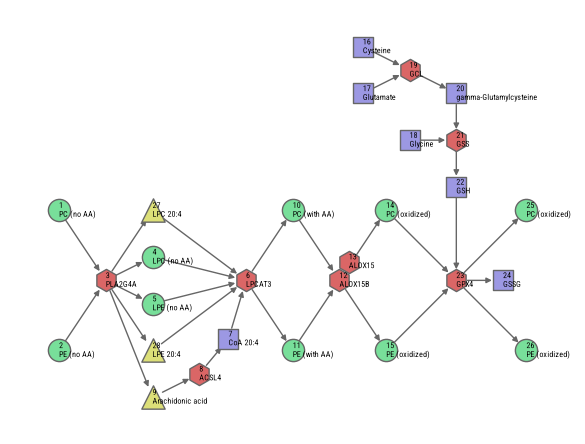

In [48]:
manager.reconnect()
pathway = load_pathway(manager, 1)
manager.close()
ax = plot_pathway_layout(
    pathway, 
    label_font_family="Roboto Condensed", 
    node_pos={
        n: (d["x"], d["y"])
        for n, d in pathway.nodes(data=True)
    },
    figsize=(6, 6)
)

### Map omics data onto pathway

#### Proteomics

In [49]:
# load the identifiers and statistics from input CSV
# then map data onto the pathway
map_omics_data_to_pathway(
    pathway,
    "proteomics",
    *load_stats_from_csv(
        PROCESSED_OMICS_DATA["proteomics"],
        stat_type="∆z",
        group_comparison="nmf2 vs. nmf1/3"
    )
)

#### Transcriptomics

In [50]:
# load the identifiers and statistics from input CSV
# then map data onto the pathway
map_omics_data_to_pathway(
    pathway,
    "transcriptomics",
    *load_stats_from_csv(
        PROCESSED_OMICS_DATA["transcriptomics"],
        stat_type="∆z",
        group_comparison="nmf2 vs. nmf1/3"
    )
)

#### Metabolomics

In [51]:
# load the identifiers and statistics from input CSV
# then map data onto the pathway
map_omics_data_to_pathway(
    pathway,
    "metabolomics",
    *load_stats_from_csv(
        PROCESSED_OMICS_DATA["metabolomics"],
        stat_type="∆z",
        group_comparison="nmf2 vs. nmf1/3"
    )
)

#### Lipidomics

In [52]:
# load the identifiers and statistics from input CSV
# then map data onto the pathway
map_omics_data_to_pathway(
    pathway,
    "lipidomics",
    *load_stats_from_csv(
        PROCESSED_OMICS_DATA["lipidomics"],
        stat_type="∆z",
        group_comparison="nmf2 vs. nmf1/3"
    )
)

### Plot pathway with mapped omics data

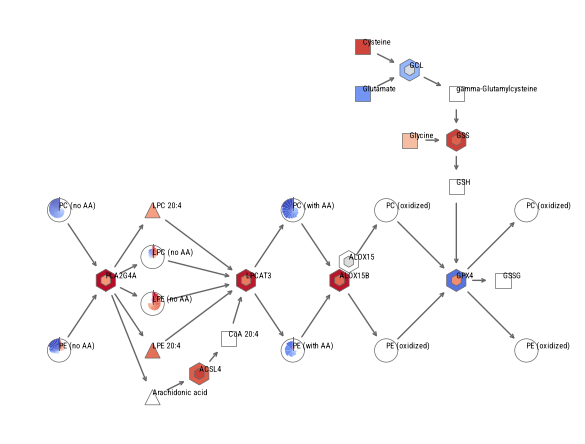

In [53]:
ax = plot_pathway_stats(
    pathway, 
    label_font_family="Roboto Condensed", 
    node_pos={
        n: (d["x"], d["y"])
        for n, d in pathway.nodes(data=True)
    },
    figsize=(6, 6),
    lipid_pie_r=0.5,
    figname=os.path.join(FIGURES_DIR, "mapped.png"),
    scale_radius=True
)